<a href="https://colab.research.google.com/github/mairsor/Random-Forest-for-Churn-Prediction-in-a-Telecom-Company-in-Peru/blob/main/project_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.Dataset & Data preprocessing**
**Dataset utilizado:** El dataset es proporcionado por la empresa Claro para la elaboración de esta investigación.

**Sección 1 – Instalación e importación de librerías**

In [ ]:
#Instalar las librerías
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Configuración visual para los gráficos
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


**Sección 2 – Carga del Dataset**

In [ ]:
import os

NOMBRE_ARCHIVO = None  # se completa automáticamente abajo

try:
    # Si estamos en Google Colab, mostramos el selector de archivos
    from google.colab import files
    print('Sube tu archivo CSV:')
    subido = files.upload()
    NOMBRE_ARCHIVO = list(subido.keys())[0]
    print(f'Archivo subido: {NOMBRE_ARCHIVO}')
except ImportError:
    # Si NO estamos en Colab (Jupyter local, VSCode, etc.),
    # indica aquí la ruta de tu archivo CSV
    NOMBRE_ARCHIVO = 'tu_archivo.csv'  # <-- CAMBIA esto por la ruta real de tu CSV
    if not os.path.exists(NOMBRE_ARCHIVO):
        raise FileNotFoundError(
            f'No se encontró \'{NOMBRE_ARCHIVO}\'. '
            'Edita la variable NOMBRE_ARCHIVO con la ruta correcta de tu CSV.'
        )
    print(f'Usando archivo local: {NOMBRE_ARCHIVO}')

Sube tu archivo CSV:


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Archivo subido: WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
# Cargar el dataset en un DataFrame
df = pd.read_csv(NOMBRE_ARCHIVO)

print(f'Dimensiones del dataset: {df.shape[0]} registros x {df.shape[1]} variables')
print()
df.head()

Dimensiones del dataset: 7043 registros x 21 variables



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Sección 3 – Análisis Exploratorio Inicial (EDA)**

In [ ]:
# Verificar valores nulos por columna
nulos = df.isnull().sum()
print('=== Valores nulos por columna ===')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'No se detectaron valores nulos directos.')

# Nota: TotalCharges tiene espacios vacíos (' ') que pandas no detecta como NaN.
# Esto se tratará en la etapa de limpieza.

=== Valores nulos por columna ===
No se detectaron valores nulos directos.


In [ ]:
# Clasificación de variables: numéricas vs categóricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas ({len(numericas)}): {numericas}')
print()
print(f'Variables categóricas ({len(categoricas)}): {categoricas}')

Variables numéricas (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Variables categóricas (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


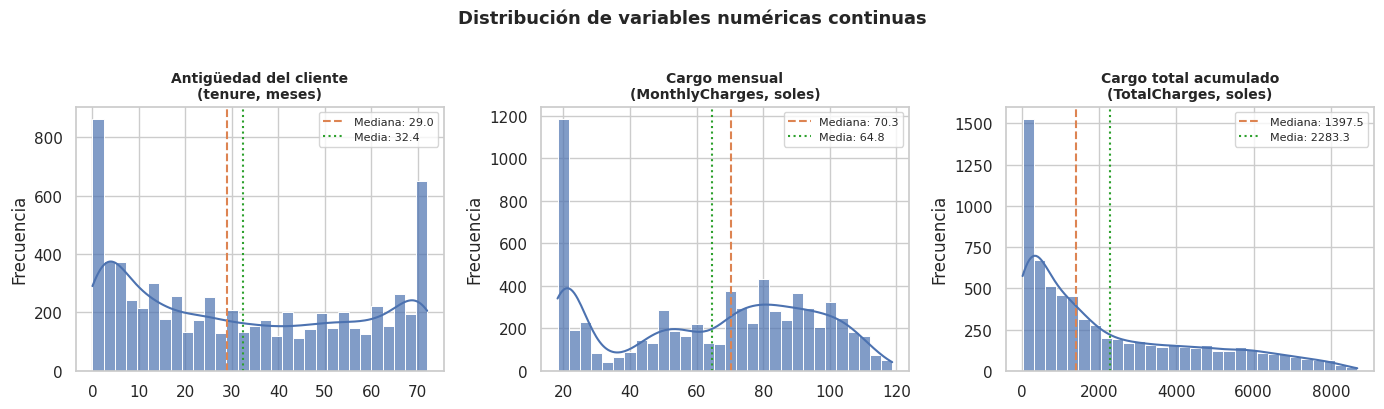

In [ ]:
# ── Fig. X: Distribución de variables numéricas continuas ──────────────────
# Ejecutar en Sección 3 – EDA, antes de la limpieza formal

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']
titulos  = ['Antigüedad del cliente\n(tenure, meses)',
            'Cargo mensual\n(MonthlyCharges, soles)',
            'Cargo total acumulado\n(TotalCharges, soles)']
color = '#4C72B0'

for ax, col, titulo in zip(axes, cols_num, titulos):
    serie = pd.to_numeric(df[col], errors='coerce').dropna()  # conversión local solo para graficar
    mediana = serie.median()
    media   = serie.mean()
    sns.histplot(serie, kde=True, ax=ax, color=color, bins=30, alpha=0.7)
    ax.axvline(mediana, color='#DD8452', linestyle='--', linewidth=1.5,
               label=f'Mediana: {mediana:.1f}')
    ax.axvline(media,   color='#2ca02c', linestyle=':',  linewidth=1.5,
               label=f'Media: {media:.1f}')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas continuas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_distribucion_numericas.png', dpi=150, bbox_inches='tight')
plt.show()

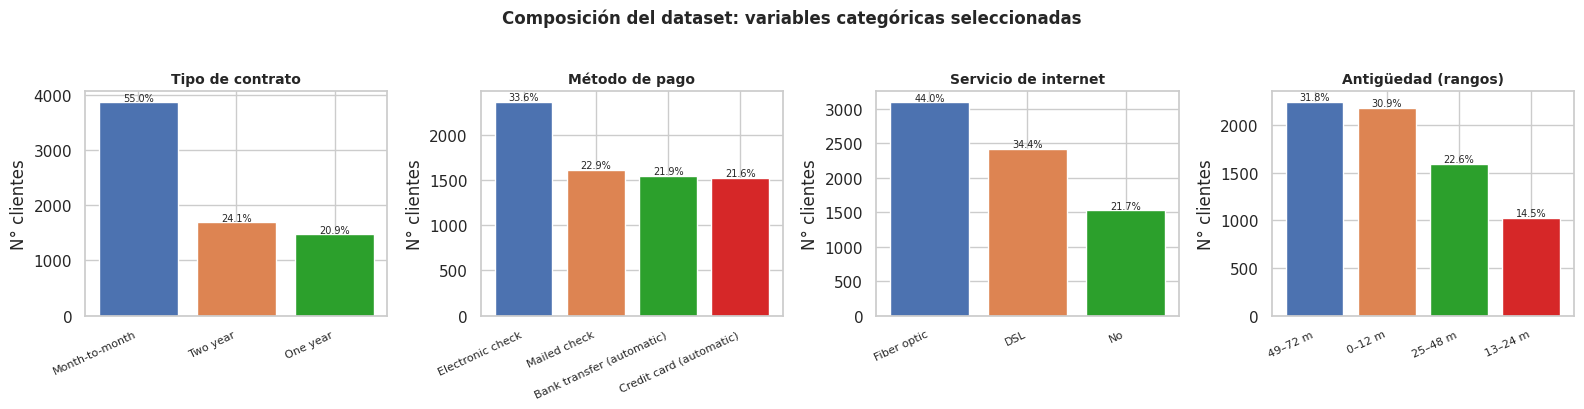

In [ ]:
# ── Fig. X: Composición de variables categóricas del dataset ───────────────
# Ejecutar sobre el df original (antes de codificación)

vars_cat = ['Contract', 'PaymentMethod', 'InternetService', 'tenure_group']

# Crear tenure_group para visualización
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0–12 m', '13–24 m', '25–48 m', '49–72 m'])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titulos = ['Tipo de contrato', 'Método de pago',
           'Servicio de internet', 'Antigüedad (rangos)']
colores = ['#4C72B0','#DD8452','#2ca02c','#d62728',
           '#9467bd','#8c564b','#e377c2']

for ax, col, titulo in zip(axes, vars_cat, titulos):
    conteos = df[col].value_counts()
    bars = ax.bar(range(len(conteos)), conteos.values,
                  color=colores[:len(conteos)], edgecolor='white')
    ax.set_xticks(range(len(conteos)))
    ax.set_xticklabels(conteos.index, rotation=25, ha='right', fontsize=8)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylabel('N° clientes')
    for bar, val in zip(bars, conteos.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 20,
                f'{val/len(df)*100:.1f}%', ha='center', fontsize=7)

plt.suptitle('Composición del dataset: variables categóricas seleccionadas',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

# Limpiar columna temporal
df = df.drop(columns=['tenure_group'])

**Sección 4 – Limpieza de datos**

Se siguen los criterios definidos en el paper:
- Eliminación de registros duplicados.
- Corrección de `TotalCharge[texto del enlace](https://)s`: esta columna viene como tipo `object` (string) y contiene espacios vacíos `' '` que representan valores faltantes. Se convierte a numérico y se imputan con la **mediana**.
- Eliminación de `customerID`: es un identificador sin valor predictivo.
- Imputación general: **mediana** para numéricas, **moda** para categóricas.

In [ ]:
# Eliminación de duplicados
duplicados = df.duplicated().sum()
print(f'Registros duplicados encontrados: {duplicados}')
df = df.drop_duplicates()
print(f'Dataset tras eliminar duplicados: {df.shape[0]} registros.')

# Eliminar customerID (identificador sin valor predictivo)
df = df.drop(columns=['customerID'])
print('Columna customerID eliminada.')

Registros duplicados encontrados: 0
Dataset tras eliminar duplicados: 7043 registros.
Columna customerID eliminada.


In [ ]:
# Corregir TotalCharges
# Viene como string. Los espacios vacíos se reemplazan por NaN y luego se imputan con la mediana.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nulos_tc = df['TotalCharges'].isnull().sum()
print(f'Valores nulos en TotalCharges tras conversión: {nulos_tc}')

mediana_tc = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(mediana_tc)
print(f'TotalCharges imputado con la mediana: {mediana_tc:.2f}')

Valores nulos en TotalCharges tras conversión: 11
TotalCharges imputado con la mediana: 1397.47


In [ ]:
# Imputación general del dataset
# Mediana para variables numéricas, moda para categóricas.

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f'Imputación completada. Nulos restantes: {df.isnull().sum().sum()}')
print(f'Dataset limpio: {df.shape[0]} registros x {df.shape[1]} variables')

Imputación completada. Nulos restantes: 0
Dataset limpio: 7043 registros x 20 variables


**Sección 5 – Codificación de variables categóricas**

Los modelos de Machine Learning trabajan con valores numéricos, por lo que las variables categóricas deben transformarse:

- **Label Encoding:** para variables **binarias** (solo 2 categorías, ej. `Yes/No`, `Male/Female`). Convierte directamente a 0 y 1.
- **One-Hot Encoding:** para variables **nominales** con más de 2 categorías (ej. `Contract`, `PaymentMethod`). Crea una columna nueva por cada categoría, evitando introducir un orden artificial que confundiría al modelo.

In [ ]:
# Identificar variables categóricas y clasificarlas según número de categorías únicas
cat_cols = df.select_dtypes(include='object').columns.tolist()

binarias = [col for col in cat_cols if df[col].nunique() == 2]
nominales = [col for col in cat_cols if df[col].nunique() > 2]

print(f'Variables binarias → Label Encoding ({len(binarias)}): {binarias}')
print()
print(f'Variables nominales → One-Hot Encoding ({len(nominales)}): {nominales}')

Variables binarias → Label Encoding (6): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

Variables nominales → One-Hot Encoding (10): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [ ]:
# Label Encoding para variables binarias
le = LabelEncoder()
for col in binarias:
    df[col] = le.fit_transform(df[col])

print('Label Encoding aplicado a:', binarias)

# One-Hot Encoding para variables nominales
# drop_first=True elimina una columna por variable para evitar multicolinealidad perfecta.

df = pd.get_dummies(df, columns=nominales, drop_first=True)

print('One-Hot Encoding aplicado a:', nominales)
print(f'Dataset tras codificación: {df.shape[0]} registros x {df.shape[1]} variables')
df.head(3)

Label Encoding aplicado a: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
One-Hot Encoding aplicado a: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Dataset tras codificación: 7043 registros x 31 variables


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


**Sección 6 – Normalización con StandardScaler**

Se estandarizan las variables numéricas continuas a media = 0 y desviación estándar = 1.

El paper indica que esta transformación se aplica para garantizar la reproducibilidad del pipeline y facilitar la comparación futura con otros clasificadores que sí dependen de la escala (como SVM o Regresión Logística).

**Importante:** Primero separamos el dataset en train y test, y el scaler se ajusta solo con los datos de entrenamiento. Luego se aplica (transforma) sobre ambos conjuntos.

In [ ]:
# Separar features (X) y variable objetivo (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# División train / test: 80% entrenamiento, 20% prueba
# random_state=42 garantiza reproducibilidad
# stratify=y mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'División completada:')
print(f'   Entrenamiento: {X_train.shape[0]} registros')
print(f'   Prueba:        {X_test.shape[0]} registros')

División completada:
   Entrenamiento: 5634 registros
   Prueba:        1409 registros


In [ ]:
# Columnas numéricas continuas a normalizar
cols_escalar = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

# fit_transform sobre train: el scaler aprende la media y desviación del train
X_train[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])

# Solo transform sobre test: se usa la media y desviación aprendida del train
X_test[cols_escalar] = scaler.transform(X_test[cols_escalar])

print('Normalización aplicada a:', cols_escalar)
print()
print('Estadísticas de las columnas escaladas (train):')
print(X_train[cols_escalar].describe().round(4))

Normalización aplicada a: ['tenure', 'MonthlyCharges', 'TotalCharges']

Estadísticas de las columnas escaladas (train):
          tenure  MonthlyCharges  TotalCharges
count  5634.0000       5634.0000     5634.0000
mean     -0.0000         -0.0000       -0.0000
std       1.0001          1.0001        1.0001
min      -1.3223         -1.5440       -1.0021
25%      -0.9560         -0.9712       -0.8309
50%      -0.1419          0.1848       -0.3968
75%       0.9165          0.8319        0.6737
max       1.6085          1.7859        2.8027


In [ ]:
# Vista final de los datos listos para la siguiente etapa
print('=== Datasets listos para la siguiente etapa ===')
print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape} | Distribución: {y_train.value_counts().to_dict()}')
print(f'y_test:  {y_test.shape}  | Distribución: {y_test.value_counts().to_dict()}')

=== Datasets listos para la siguiente etapa ===
X_train: (5634, 30)
X_test:  (1409, 30)
y_train: (5634,) | Distribución: {0: 4139, 1: 1495}
y_test:  (1409,)  | Distribución: {0: 1035, 1: 374}


# **2. Data augmentation**

**Objetivo:** Tratar el desequilibrio de clases presente en el dataset mediante
la técnica híbrida SMOTE-ENN, aplicada exclusivamente sobre el conjunto de
entrenamiento para preservar la distribución real en el conjunto de prueba.

In [ ]:
#PARTE 2. Primero instalar la librería
# !pip install -q imbalanced-learn

# ─── Importaciones ───────────────────────────────────────────────────────────
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



***Sección 1: Diagnóstico del desequilibrio de clases***

Analizar la distribución original de la variable objetivo ANTES del balanceo. Esto permite reportar los porcentajes [X]% / [Y]% mencionados en el paper.

In [ ]:
print("=" * 55)
print("DIAGNÓSTICO DE DESEQUILIBRIO DE CLASES")
print("=" * 55)

conteo_train = y_train.value_counts()
total_train   = len(y_train)

pct_retenidos = conteo_train[0] / total_train * 100
pct_abandono  = conteo_train[1] / total_train * 100

print(f"\nConjunto de entrenamiento ({total_train} registros):")
print(f"  Clase 0 – Clientes retenidos : {conteo_train[0]:>5}  ({pct_retenidos:.2f}%)")
print(f"  Clase 1 – Clientes que abandonaron: {conteo_train[1]:>5}  ({pct_abandono:.2f}%)")
print(f"\n  → Ratio de desequilibrio: {pct_retenidos/pct_abandono:.2f}:1")





DIAGNÓSTICO DE DESEQUILIBRIO DE CLASES

Conjunto de entrenamiento (5634 registros):
  Clase 0 – Clientes retenidos :  4139  (73.46%)
  Clase 1 – Clientes que abandonaron:  1495  (26.54%)

  → Ratio de desequilibrio: 2.77:1


***Sección 2: Aplicación de SMOTE-ENN***

SMOTE genera instancias sintéticas de la clase minoritaria interpolando entre vecinos cercanos en el espacio de características. ENN elimina posteriormente los ejemplos ruidosos o ambiguos de ambas clases, produciendo un conjunto de entrenamiento más limpio y balanceado.
Parámetros clave:
- random_state=42  → reproducibilidad
- smote__k_neighbors=5 → vecinos usados por SMOTE para interpolación (default)
- enn__n_neighbors=3   → vecinos usados por ENN para detección de ruido (default)

In [ ]:
print("\n" + "=" * 55)
print("APLICANDO SMOTE-ENN (solo sobre X_train / y_train)")
print("=" * 55)

smote_enn = SMOTEENN(
    smote=SMOTE(k_neighbors=5, random_state=42),
    enn=EditedNearestNeighbours(n_neighbors=3),
    random_state=42
)

X_train_bal, y_train_bal = smote_enn.fit_resample(X_train, y_train)




APLICANDO SMOTE-ENN (solo sobre X_train / y_train)


***Sección 3: Diagnóstico post-balanceo***


Conjunto de entrenamiento BALANCEADO (7163 registros):
  Clase 0 – Clientes retenidos :  4139  (57.78%)
  Clase 1 – Clientes que abandonaron:  3024  (42.22%)

  → Ratio de desequilibrio tras SMOTE-ENN: 1.37:1

  Instancias añadidas netas: +1529


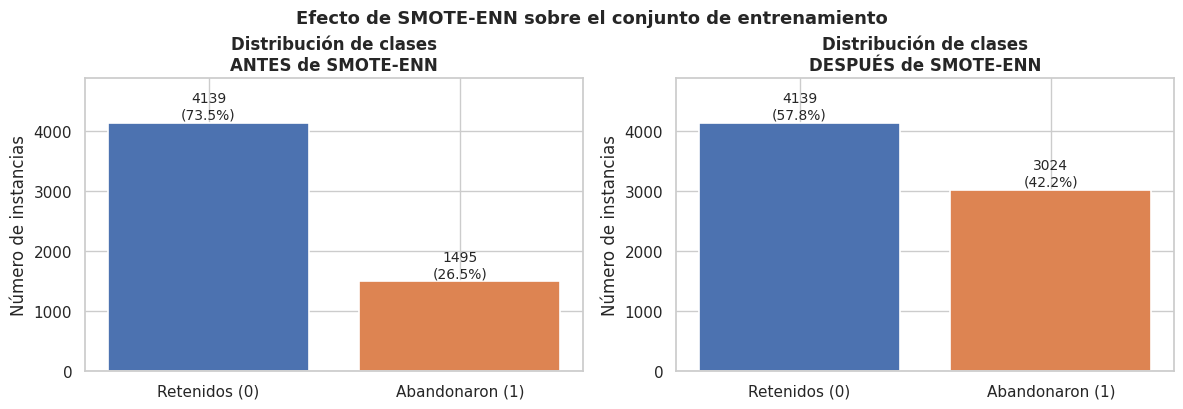

In [ ]:
conteo_bal  = pd.Series(y_train_bal).value_counts().sort_index()
total_bal   = len(y_train_bal)

pct_ret_bal = conteo_bal[0] / total_bal * 100
pct_aba_bal = conteo_bal[1] / total_bal * 100

print(f"\nConjunto de entrenamiento BALANCEADO ({total_bal} registros):")
print(f"  Clase 0 – Clientes retenidos : {conteo_bal[0]:>5}  ({pct_ret_bal:.2f}%)")
print(f"  Clase 1 – Clientes que abandonaron: {conteo_bal[1]:>5}  ({pct_aba_bal:.2f}%)")
print(f"\n  → Ratio de desequilibrio tras SMOTE-ENN: {pct_ret_bal/pct_aba_bal:.2f}:1")
print(f"\n  Instancias añadidas netas: {total_bal - total_train:+d}")


# ── Visualización: distribución de clases ANTES vs DESPUÉS de SMOTE-ENN ──
colores = ['#4C72B0', '#DD8452']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (Izquierda) ANTES del balanceo
axes[0].bar(['Retenidos (0)', 'Abandonaron (1)'],
            [conteo_train[0], conteo_train[1]],
            color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de clases\nANTES de SMOTE-ENN', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de instancias')
for i, v in enumerate([conteo_train[0], conteo_train[1]]):
    axes[0].text(i, v + 20, f'{v}\n({[pct_retenidos, pct_abandono][i]:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, max(conteo_train[0], conteo_train[1]) * 1.18)

# (Derecha) DESPUÉS del balanceo
axes[1].bar(['Retenidos (0)', 'Abandonaron (1)'],
            [conteo_bal[0], conteo_bal[1]],
            color=colores, edgecolor='white', linewidth=1.2)
axes[1].set_title('Distribución de clases\nDESPUÉS de SMOTE-ENN', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de instancias')
for i, v in enumerate([conteo_bal[0], conteo_bal[1]]):
    axes[1].text(i, v + 20, f'{v}\n({[pct_ret_bal, pct_aba_bal][i]:.1f}%)',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, max(conteo_bal[0], conteo_bal[1]) * 1.18)

plt.tight_layout()
plt.suptitle('Efecto de SMOTE-ENN sobre el conjunto de entrenamiento',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()


***SECCIÓN 4: Resumen final y verificación***

In [ ]:

print("\n" + "=" * 55)
print("RESUMEN — CONJUNTOS LISTOS PARA LA SIGUIENTE ETAPA")
print("=" * 55)
print(f"  X_train_bal : {X_train_bal.shape}  ← usar en entrenamiento")
print(f"  y_train_bal : {y_train_bal.shape}")
print(f"  X_test      : {X_test.shape}        ← sin modificar (eval. realista)")
print(f"  y_test      : {y_test.shape}")
print()
print("  NOTA: el conjunto de prueba conserva la distribución original.")
print("  SMOTE-ENN se aplicó EXCLUSIVAMENTE sobre el conjunto de entrenamiento.")

# Output — Formato esperado por las siguientes etapas
datos = {
    "X_train_bal": X_train_bal,
    "y_train_bal": y_train_bal,
    "X_test":      X_test,
    "y_test":      y_test
}


RESUMEN — CONJUNTOS LISTOS PARA LA SIGUIENTE ETAPA
  X_train_bal : (7163, 30)  ← usar en entrenamiento
  y_train_bal : (7163,)
  X_test      : (1409, 30)        ← sin modificar (eval. realista)
  y_test      : (1409,)

  NOTA: el conjunto de prueba conserva la distribución original.
  SMOTE-ENN se aplicó EXCLUSIVAMENTE sobre el conjunto de entrenamiento.


# **Feature selection**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# ============================================================
# ETAPA 1: FILTRO DE CORRELACIÓN DE PEARSON
# Eliminamos variables redundantes antes de entrenar el modelo
# ============================================================

# Calculamos la correlación absoluta entre todas las variables
corr_matrix = X_train_bal.corr(method='pearson').abs()

# Usamos solo el triángulo superior para no comparar el mismo par dos veces
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Si dos variables tienen correlación > 0.85, eliminamos una de ellas
variables_a_eliminar = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > 0.85)
]

print(f"Variables eliminadas por alta correlación: {variables_a_eliminar}")

# Aplicamos la eliminación tanto a train como a test
X_train_filtrado = X_train_bal.drop(columns=variables_a_eliminar)
X_test_filtrado  = X_test.drop(columns=variables_a_eliminar)

print(f"Variables restantes tras filtro de Pearson: {X_train_filtrado.shape[1]}")

Variables eliminadas por alta correlación: ['MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']
Variables restantes tras filtro de Pearson: 23


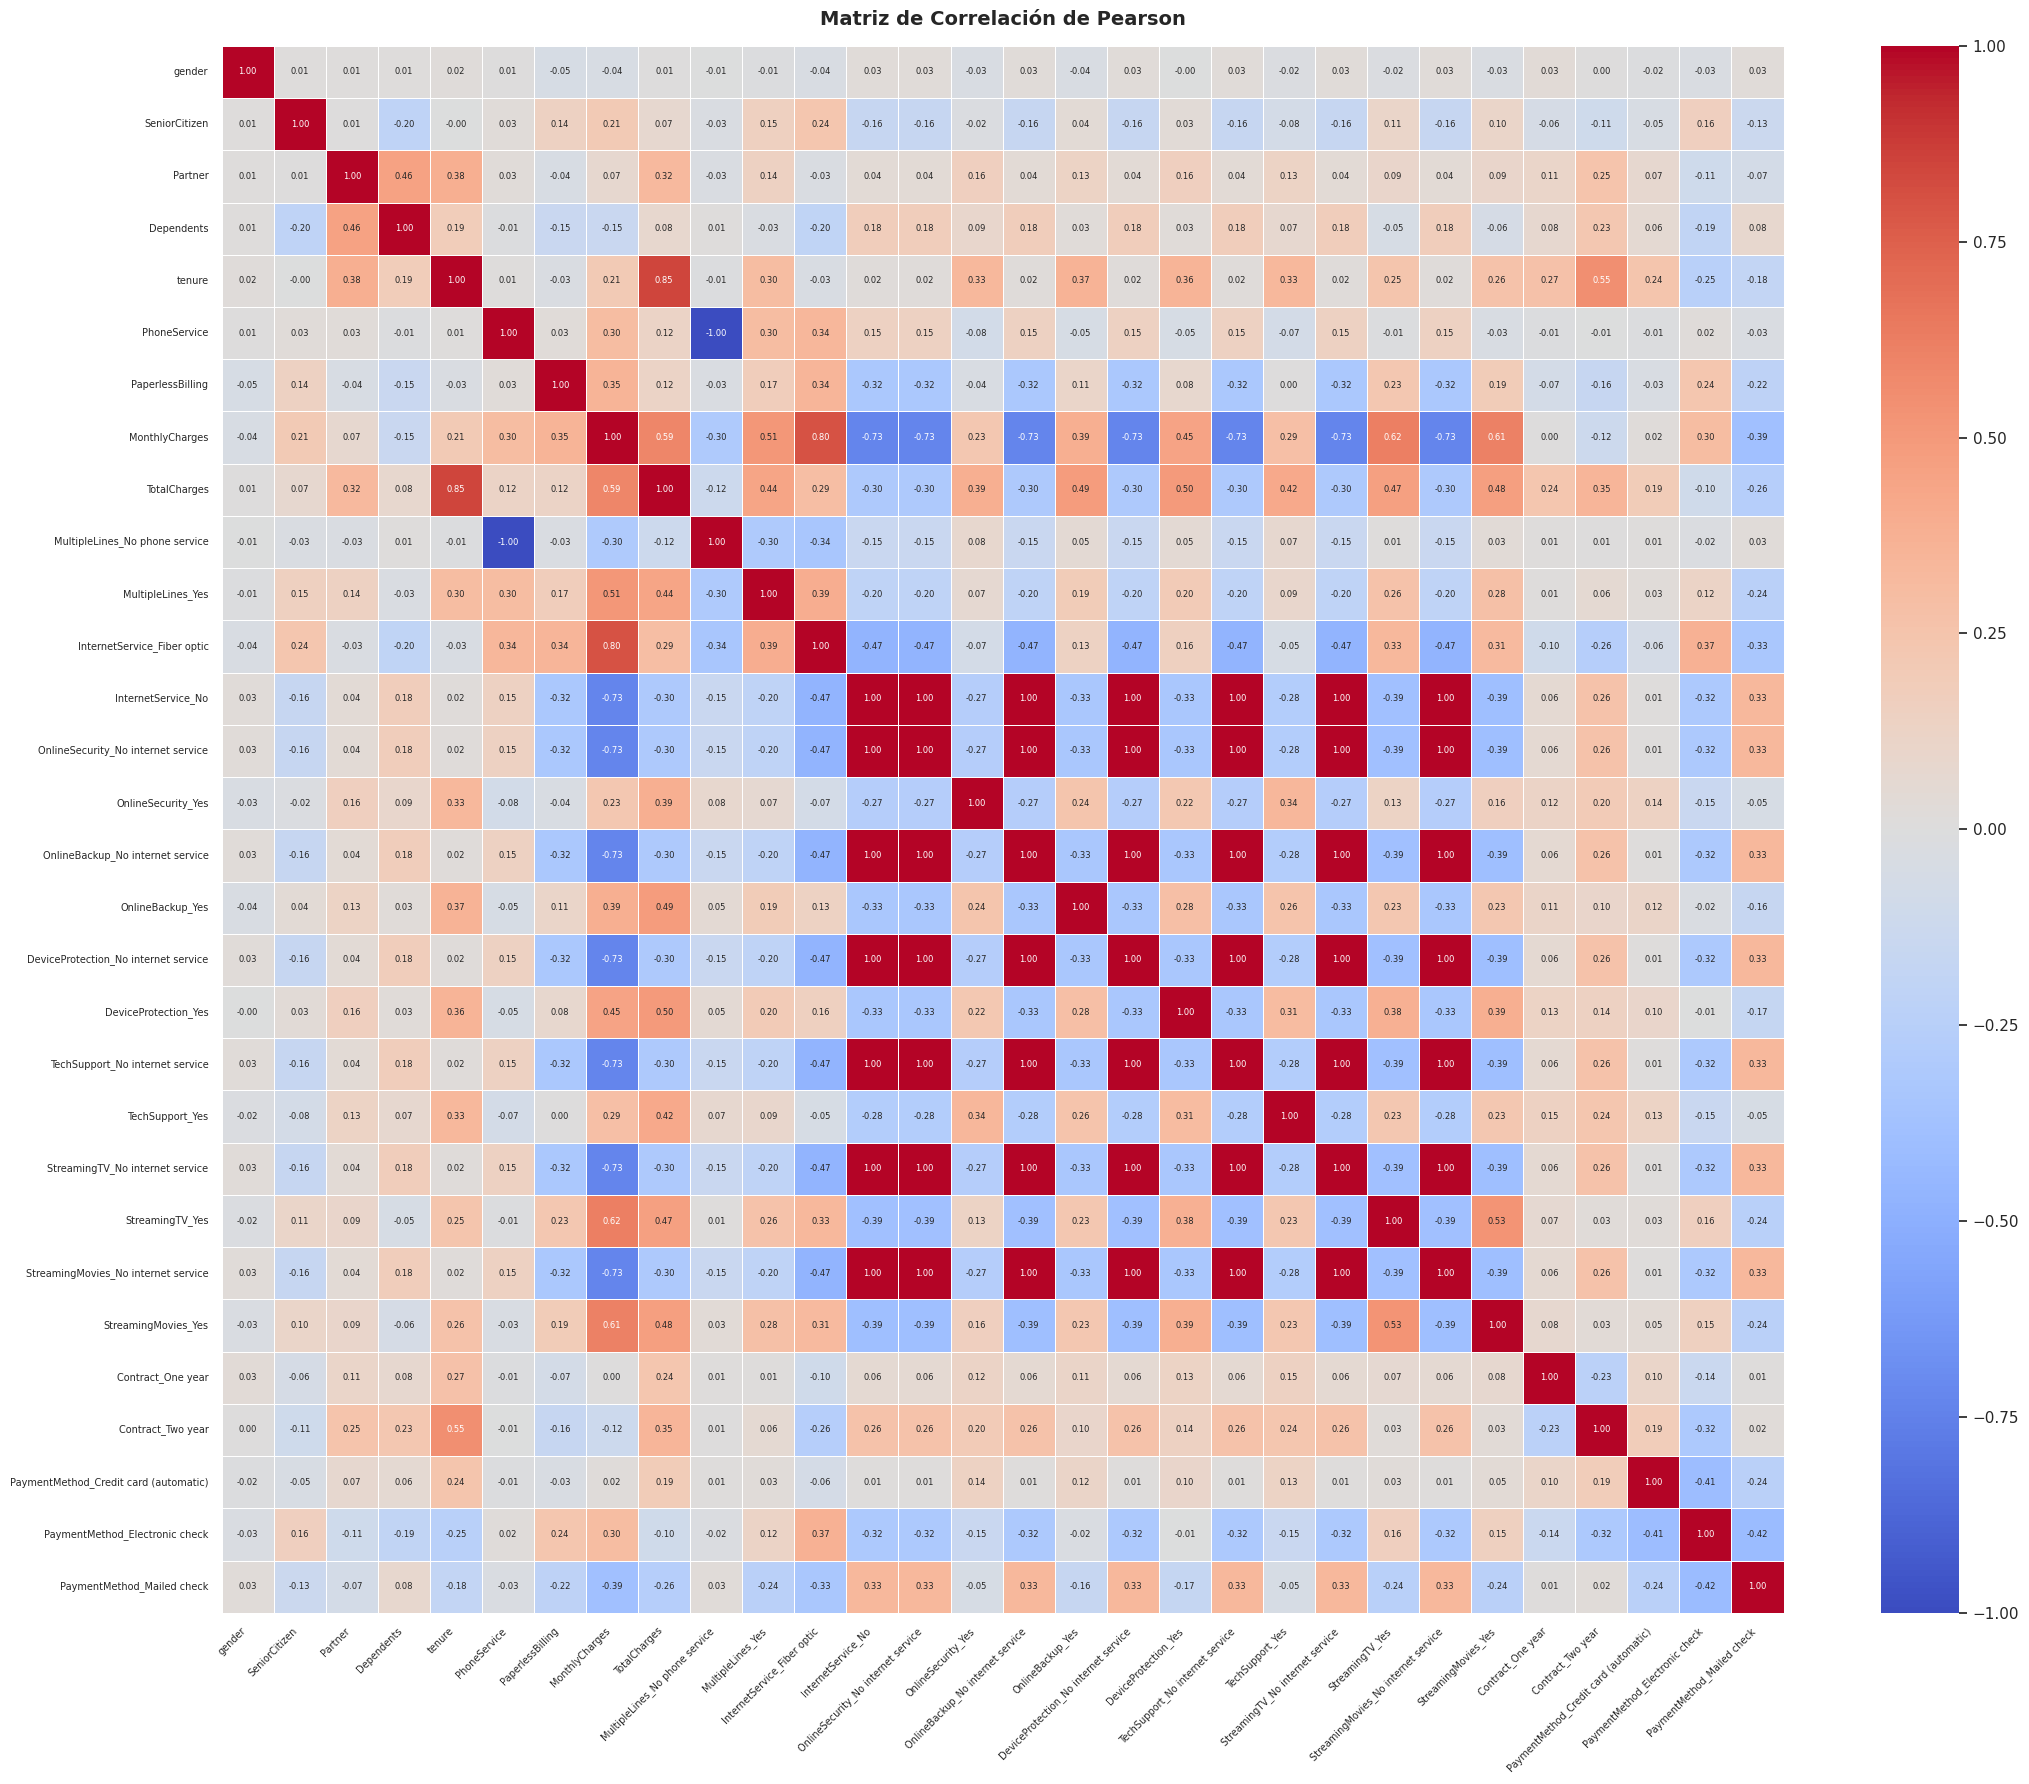

In [ ]:
# Visualizamos la matriz de correlación para identificar
# gráficamente los pares de variables redundantes
plt.figure(figsize=(22, 18))
sns.heatmap(X_train_bal.corr(method='pearson'),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            annot_kws={"size": 6},
            linewidths=0.5,
            linecolor='white')
plt.title('Matriz de Correlación de Pearson', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ETAPA 2: IMPORTANCIA DE VARIABLES POR IMPUREZA DE GINI
# Entrenamos un RF rápido solo para rankear las variables
# ============================================================

# Entrenamos el modelo con las variables ya filtradas
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_filtrado, y_train_bal)

# Extraemos la importancia de cada variable y las ordenamos de mayor a menor
importancias = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_filtrado.columns
).sort_values(ascending=False)

# Calculamos cuánto va acumulando cada variable en orden de importancia
importancia_acumulada = importancias.cumsum()

# Nos quedamos con las variables que juntas llegan al 95% de importancia total
variables_seleccionadas = importancia_acumulada[
    importancia_acumulada <= 0.95
].index.tolist()

# Incluimos la variable que cruza el umbral del 95% para no perder información
if len(variables_seleccionadas) < len(importancias):
    variables_seleccionadas.append(
        importancia_acumulada[importancia_acumulada > 0.95].index[0]
    )

print(f"Variables seleccionadas ({len(variables_seleccionadas)}): {variables_seleccionadas}")

Variables seleccionadas (20): ['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'PaymentMethod_Electronic check', 'Contract_Two year', 'gender', 'PaperlessBilling', 'InternetService_No', 'Partner', 'Dependents', 'Contract_One year', 'MultipleLines_Yes', 'StreamingMovies_Yes', 'TechSupport_Yes', 'OnlineBackup_Yes', 'OnlineSecurity_Yes', 'StreamingTV_Yes', 'DeviceProtection_Yes', 'SeniorCitizen']


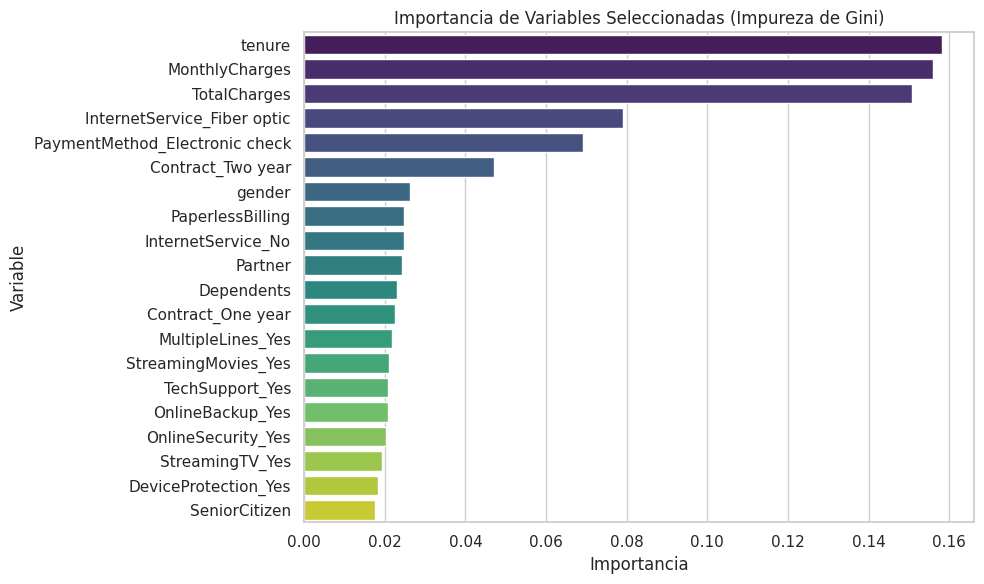

In [ ]:
# Graficamos las variables seleccionadas ordenadas por importancia
# para visualizar cuáles influyen más en la predicción del churn
plt.figure(figsize=(10, 6))
sns.barplot(x=importancias[variables_seleccionadas],
            y=variables_seleccionadas, palette='viridis')
plt.title('Importancia de Variables Seleccionadas (Impureza de Gini)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
#  Variables listas para el modelo Random Forest
# ============================================================

# Aplicamos la selección final a train y test con las mismas variables
X_train_selected = X_train_filtrado[variables_seleccionadas]
X_test_selected  = X_test_filtrado[variables_seleccionadas]

# Resumen de lo que recibe el siguiente compañero
print("=== OUTPUT PARA RANDOM FOREST ===")
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected:  {X_test_selected.shape}")
print(f"y_train_bal y y_test se mantienen igual")
print(f"\nVariables finales: {list(X_train_selected.shape)}")

=== OUTPUT PARA RANDOM FOREST ===
X_train_selected: (7163, 20)
X_test_selected:  (1409, 20)
y_train_bal y y_test se mantienen igual

Variables finales: [7163, 20]


# **Random forest y definición operacional de variables**

In [ ]:
# Parte 4
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import math

print("Librerías de la Parte 4 importadas correctamente.")
print(f"Número de atributos (features): {X_train.shape[1]}")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Distribución y_train → {y_train.value_counts().to_dict()}")
print(f"Distribución y_test  → {y_test.value_counts().to_dict()}")


Librerías de la Parte 4 importadas correctamente.


NameError: name 'X_train' is not defined

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores hiperparámetros encontrados:")
for param, valor in grid_search.best_params_.items():
    print(f"   {param}: {valor}")
print(f"Mejor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Mejores hiperparámetros encontrados:
   class_weight: balanced
   max_depth: 10
   min_samples_leaf: 4
   min_samples_split: 10
   n_estimators: 100
Mejor F1 (CV): 0.6375


In [ ]:
n_train = X_train.shape[0]
n_bootstrap = int(n_train * 0.8)

print(f"Registros en el conjunto de entrenamiento : {n_train}")
print(f"Registros por muestra bootstrap (80%)     : {n_bootstrap}")
print(f"Registros reservados para OOB (~20%)      : {n_train - n_bootstrap}")



Registros en el conjunto de entrenamiento : 5634
Registros por muestra bootstrap (80%)     : 4507
Registros reservados para OOB (~20%)      : 1127


In [ ]:
n_features = X_train.shape[1]
max_features_valor = math.sqrt(n_features)

print(f"Total de atributos del dataset     : {n_features}")
print(f"sqrt({n_features}) = {max_features_valor:.2f}  → se usa max_features='sqrt'")



Total de atributos del dataset     : 30
sqrt(30) = 5.48  → se usa max_features='sqrt'


In [ ]:
best_params = grid_search.best_params_

rf_final = RandomForestClassifier(
    **best_params,
    max_features='sqrt',        # Paso 4: √21 ≈ 5.5 → 5 atributos por split
    bootstrap=True,             # Paso 3: Bagging activado
    oob_score=True,             # Estimación del error Out-Of-Bag
    random_state=42
)

rf_final.fit(X_train, y_train)

print(f"Modelo entrenado correctamente.")
print(f"OOB Score (estimación interna de accuracy): {rf_final.oob_score_:.4f}")


Modelo entrenado correctamente.
OOB Score (estimación interna de accuracy): 0.7709


Top 15 atributos más influyentes:

    1. tenure                                        0.1807
    2. TotalCharges                                  0.1354
    3. Contract_Two year                             0.1071
    4. MonthlyCharges                                0.0895
    5. InternetService_Fiber optic                   0.0753
    6. PaymentMethod_Electronic check                0.0593
    7. Contract_One year                             0.0421
    8. OnlineSecurity_Yes                            0.0290
    9. TechSupport_Yes                               0.0274
   10. OnlineSecurity_No internet service            0.0234
   11. PaperlessBilling                              0.0199
   12. OnlineBackup_No internet service              0.0179
   13. StreamingMovies_No internet service           0.0176
   14. TechSupport_No internet service               0.0155
   15. OnlineBackup_Yes                              0.0148


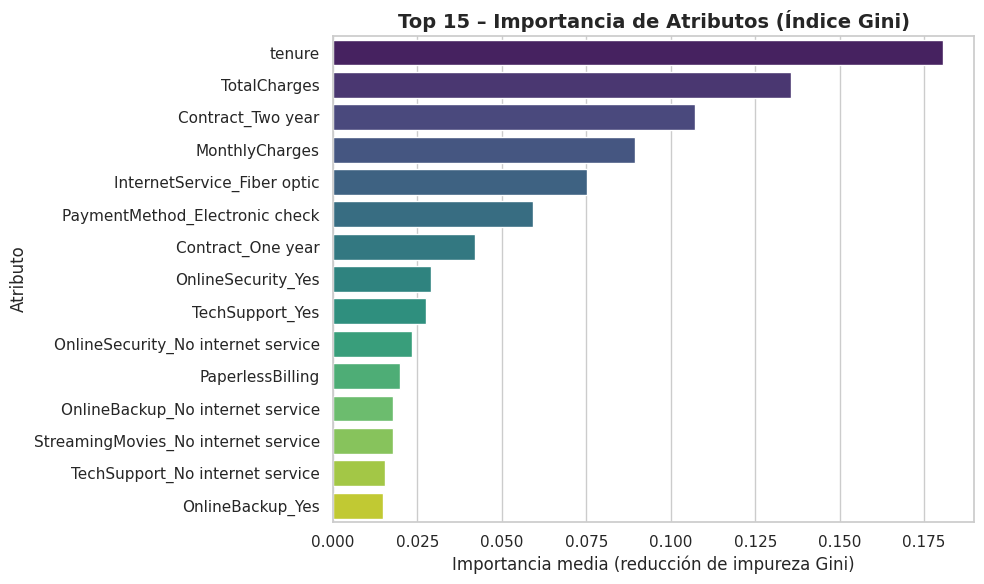

In [ ]:
importancias = pd.Series(
    rf_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Top 15 atributos más influyentes
top_n = 15
importancias_top = importancias.head(top_n)

print(f"Top {top_n} atributos más influyentes:\n")
for i, (attr, valor) in enumerate(importancias_top.items(), 1):
    print(f"   {i:>2}. {attr:<45} {valor:.4f}")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=importancias_top.values,
    y=importancias_top.index,
    palette='viridis',
    ax=ax
)
ax.set_title(f'Top {top_n} – Importancia de Atributos (Índice Gini)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia media (reducción de impureza Gini)')
ax.set_ylabel('Atributo')
plt.tight_layout()
plt.show()


Matriz de Confusión:
   Verdaderos Negativos (TN) – No churn correctamente predicho : 790
   Falsos Positivos     (FP) – No churn predicho como churn    : 245
   Falsos Negativos     (FN) – Churn NO detectado              : 87
   Verdaderos Positivos (TP) – Churn correctamente detectado   : 287


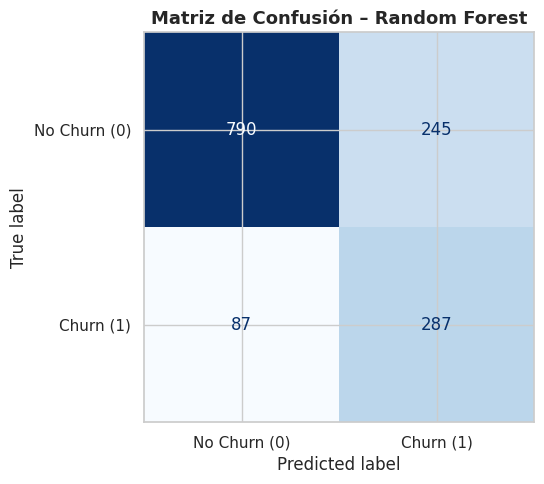


Reporte de Clasificación:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.80      0.76      0.78      1409

AUC-ROC: 0.8437


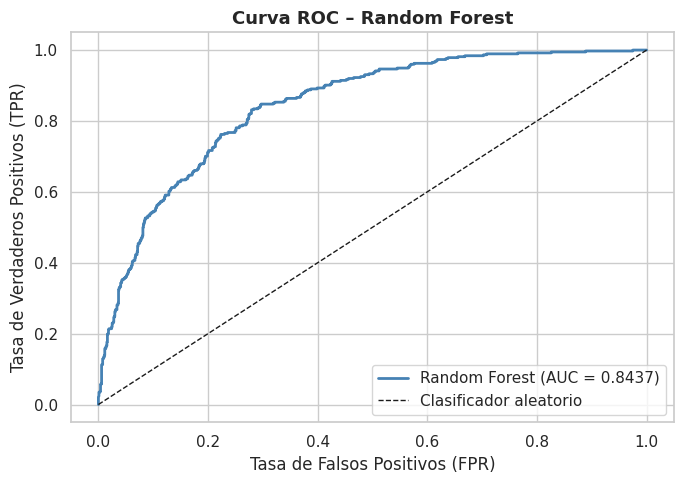


Distribución de clientes por nivel de riesgo de churn:
Nivel_Riesgo
Bajo     662
Medio    345
Alto     402
Name: count, dtype: int64

Top 10 clientes con mayor probabilidad de churn:
      P_Churn  Churn_Real Nivel_Riesgo
6623   0.9388           1         Alto
4585   0.9349           1         Alto
6866   0.9324           1         Alto
3380   0.9307           1         Alto
2194   0.9293           1         Alto
1731   0.9284           1         Alto
2464   0.9270           1         Alto
809    0.9255           1         Alto
2927   0.9250           0         Alto
1739   0.9250           1         Alto
AUC-ROC final: 0.8437


In [ ]:

y_pred  = rf_final.predict(X_test)
y_proba = rf_final.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nMatriz de Confusión:")
print(f"   Verdaderos Negativos (TN) – No churn correctamente predicho : {tn}")
print(f"   Falsos Positivos     (FP) – No churn predicho como churn    : {fp}")
print(f"   Falsos Negativos     (FN) – Churn NO detectado              : {fn}")
print(f"   Verdaderos Positivos (TP) – Churn correctamente detectado   : {tp}")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión – Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC – Random Forest', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


resultados = X_test.copy()
resultados['Churn_Real']        = y_test.values
resultados['Churn_Predicho']    = y_pred
resultados['P_Churn']           = y_proba.round(4)

resultados['Nivel_Riesgo'] = pd.cut(
    resultados['P_Churn'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

print("\nDistribución de clientes por nivel de riesgo de churn:")
print(resultados['Nivel_Riesgo'].value_counts().sort_index())

print("\nTop 10 clientes con mayor probabilidad de churn:")
print(
    resultados[['P_Churn', 'Churn_Real', 'Nivel_Riesgo']]
    .sort_values('P_Churn', ascending=False)
    .head(10)
    .to_string()
)

print(f"AUC-ROC final: {auc:.4f}")